# NYC 311 Service Requests Analysis

## Project Summary
This project explores NYC 311 service request data to identify complaint patterns, response behavior, and data quality issues. The notebook is written as a report-style analysis, with clear sections, short explanations, and visual findings to make it suitable for a CV portfolio.

## Dataset Overview
The dataset contains NYC 311 service request records, which capture complaints submitted by residents across the city. It includes information such as created date, closed date, complaint type, borough, location type, and agency response.

The data is large enough to support meaningful analysis, but it also contains real-world quality issues such as missing values, inconsistent dates, and unresolved complaints. That makes it a strong dataset for demonstrating practical data cleaning, validation, and exploratory analysis skills.

## Dataset Structure
The dataset contains 111,069 NYC 311 service requests across 14 variables. The most important fields are the complaint metadata and time stamps: `Created Date`, `Closed Date`, `Complaint Type`, `Agency`, `Borough`, and `Status`. These variables allow the analysis to examine when complaints were reported, how long they remained open, which agencies handled them, and where they occurred.

The remaining fields add useful context. `Descriptor` explains the issue in more detail, `Location Type` and `Address Type` describe where the problem happened, and `Incident Zip`, `City`, and `Borough` provide geographic information. `Agency Name` gives the full department name, while `Landmark` and `Unnamed: 0` are mostly administrative or low-value fields that require cleaning or removal. This structure makes the dataset suitable for time-based analysis, location-based analysis, and agency-level service review.

## Questions and Goals
This project focuses on understanding how NYC 311 service requests are distributed and handled across the city.

- Analyze which complaint types appear most often in the dataset.
- Analyze which agencies receive the most requests and how they respond.
- Analyze which locations and ZIP codes generate the most complaints.
- Analyze whether certain complaint types are concentrated in specific boroughs or neighborhoods.
- Analyze which complaint types take the longest to resolve and whether resolution time varies by agency or location.
- Optionally, build a simple predictive model to estimate resolution time or identify complaints that are more likely to stay open.


In [36]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# load the raw data 
df = pd.read_csv("data/311-service-requests.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()

Dataset shape: (111069, 14)

Column names and types:
Unnamed: 0         int64
Created Date      object
Closed Date       object
Agency            object
Agency Name       object
Complaint Type    object
Descriptor        object
Location Type     object
Incident Zip      object
Address Type      object
City              object
Landmark          object
Status            object
Borough           object
dtype: object

First few rows:


,Unnamed: 0,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Address Type,City,Landmark,Status,Borough
0,0,10/31/2013 02:08:41 AM,NaN,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Talking,Street/Sidewalk,11432.0,ADDRESS,JAMAICA,NaN,Assigned,QUEENS
1,1,10/31/2013 02:01:04 AM,NaN,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,11378.0,BLOCKFACE,MASPETH,NaN,Open,QUEENS
2,2,10/31/2013 02:00:24 AM,10/31/2013 02:40:32 AM,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,Club/Bar/Restaurant,10032.0,ADDRESS,NEW YORK,NaN,Closed,MANHATTAN
3,3,10/31/2013 01:56:23 AM,10/31/2013 02:21:48 AM,NYPD,New York City Police Department,Noise - Vehicle,Car/Truck Horn,Street/Sidewalk,10023.0,BLOCKFACE,NEW YORK,NaN,Closed,MANHATTAN
4,4,10/31/2013 01:53:44 AM,NaN,DOHMH,Department of Health and Mental Hygiene,Rodent,Condition Attracting Rodents,Vacant Lot,10027.0,BLOCKFACE,NEW YORK,NaN,Pending,MANHATTAN


### Interpretation
The dataset contains 111,069 rows and 14 columns, which is large enough to support meaningful analysis and trend detection. The structure is suitable for a practical data project because it includes both operational attributes such as agency, borough, and status, and temporal fields such as created date and closed date.

The column types show that the raw data includes a mix of text fields and date fields. Several columns are strings and require cleaning, while the date columns need conversion to datetime format before any time-based analysis can be performed. This is a normal and expected stage in any real-world dataset.

In [37]:
# check for missing values
print("missing value per columns")
missing = df.isnull().sum()

missing value per columns


In [38]:
missing

Unnamed: 0             0
Created Date           0
Closed Date        50799
Agency                 0
Agency Name            0
Complaint Type         0
Descriptor           456
Location Type      32047
Incident Zip       12262
Address Type        8822
City               12215
Landmark          110974
Status                 0
Borough                0
dtype: int64

In [39]:
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

Missing values per column:


In [40]:
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_df)

                Missing Count  Percentage
Landmark               110974   99.914468
Closed Date             50799   45.736434
Location Type           32047   28.853235
Incident Zip            12262   11.039984
City                    12215   10.997668
Address Type             8822    7.942810
Descriptor                456    0.410556
Complaint Type              0    0.000000
Agency                      0    0.000000
Created Date                0    0.000000
Unnamed: 0                  0    0.000000
Agency Name                 0    0.000000
Status                      0    0.000000
Borough                     0    0.000000


### Missing Data Interpretation
The missing-value audit highlights which variables are reliable and which are weak for analysis. Fields such as `Complaint Type`, `Agency`, `Created Date`, `Status`, and `Borough` have no missing values and can support the main business questions. In contrast, `Landmark` is almost entirely empty, indicating that it adds little analytical value and should be excluded.

`Closed Date` has the largest practical issue, with 45.7% missing values. This likely reflects complaints that were never closed, which is meaningful in itself and should not be treated as random noise. `Location Type`, `Incident Zip`, and `City` also show moderate missingness but remain usable with careful handling.

This result is important because it tells us which variables are strong enough for analysis and which require cleaning, flagging, or removal.

In [41]:
# Clean column names (lowercase and replace spaces with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("Column names cleaned:")
print(df.columns)

Column names cleaned:
Index(['unnamed:_0', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'location_type', 'incident_zip',
       'address_type', 'city', 'landmark', 'status', 'borough'],
      dtype='object')


In [42]:
# Convert dates to datetime
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
df['closed_date'] = pd.to_datetime(df['closed_date'], errors='coerce')

print("Date parsing results:")
print(f"created_date nulls after parsing: {df['created_date'].isnull().sum()}")
print(f"closed_date nulls after parsing: {df['closed_date'].isnull().sum()}")

print("\n" + "="*50)
print("Date range:")
print(f"created_date range: {df['created_date'].min()} to {df['created_date'].max()}")
print(f"closed_date range: {df['closed_date'].min()} to {df['closed_date'].max()}")

print("\n" + "="*50)
print("Logical check (closed_date >= created_date):")
closed_valid = df[df['closed_date'].notna()]
bad_dates = closed_valid[closed_valid['closed_date'] < closed_valid['created_date']]
print(f"Rows where closed_date < created_date: {len(bad_dates)} ({(len(bad_dates)/len(df)*100):.2f}%)")

Date parsing results:
created_date nulls after parsing: 0
closed_date nulls after parsing: 50799

Date range:
created_date range: 2013-10-04 00:00:10 to 2013-10-31 02:08:41
closed_date range: 1900-01-01 00:00:00 to 2013-10-31 03:00:20

Logical check (closed_date >= created_date):
Rows where closed_date < created_date: 2047 (1.84%)


### Date Validation
The date columns parse correctly, and `Created Date` has no missing values. `Closed Date` is missing for open complaints, which is expected in service request data. The date range is also sensible, and the logical check shows that 2,047 rows have `Closed Date` earlier than `Created Date`, indicating a small but important data-quality issue that should be flagged during cleaning.

In [43]:
# Check for duplicate rows
print("Duplicate rows check:")
print(f"Total duplicate rows: {df.duplicated().sum()}")

# Check if there are duplicates based on specific columns
print("\n" + "="*50)
print("Duplicates based on key columns (created_date, complaint_type, agency, borough):")
key_cols = ['created_date', 'complaint_type', 'agency', 'borough']
duplicates_key = df.duplicated(subset=key_cols, keep=False)
print(f"Rows with duplicate key info: {duplicates_key.sum()}")

print("\n" + "="*50)
print("Dataset shape before any cleaning:")
print(df.shape)

Duplicate rows check:
Total duplicate rows: 0

Duplicates based on key columns (created_date, complaint_type, agency, borough):
Rows with duplicate key info: 46606

Dataset shape before any cleaning:
(111069, 14)


In [44]:
# Calculate resolution time for closed complaints
df['resolution_days'] = (df['closed_date'] - df['created_date']).dt.days

print("Resolution time statistics (for closed complaints only):")
print(df['resolution_days'].describe())

print("\n" + "="*50)
print("Resolution time percentiles:")
percentiles = df['resolution_days'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print(percentiles)

print("\n" + "="*50)
print("Negative resolution times (closed before created):")
negative = df[df['resolution_days'] < 0]
print(f"Count: {len(negative)} ({(len(negative)/len(df)*100):.2f}%)")

print("\n" + "="*50)
print("Open vs Closed complaints:")
open_count = df['closed_date'].isnull().sum()
closed_count = len(df) - open_count
print(f"Open (no closed date): {open_count} ({(open_count/len(df)*100):.2f}%)")
print(f"Closed: {closed_count} ({(closed_count/len(df)*100):.2f}%)")

Resolution time statistics (for closed complaints only):
count    60270.000000
mean        -1.134478
std        293.242808
min     -41560.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         26.000000
Name: resolution_days, dtype: float64

Resolution time percentiles:
0.01    -5.0
0.05     0.0
0.25     0.0
0.50     0.0
0.75     2.0
0.95     5.0
0.99    14.0
Name: resolution_days, dtype: float64

Negative resolution times (closed before created):
Count: 2047 (1.84%)

Open vs Closed complaints:
Open (no closed date): 50799 (45.74%)
Closed: 60270 (54.26%)


### Resolution Time Audit
The resolution-time analysis shows that most closed complaints are resolved very quickly. The median is 0 days, and the 75th percentile is only 2 days, which means a large share of requests are closed within a short period. However, the mean is negative, which is a clear warning sign that some records contain invalid date logic and are pulling the average downward.

The distribution also shows that 2,047 rows have a negative resolution time, meaning `Closed Date` is earlier than `Created Date` in those cases. This is a data-quality issue that must be corrected during cleaning. In addition, 45.74% of records remain open, which is expected in service-request systems but should be treated separately from completed complaints.

Overall, the dataset suggests fast service response for most closed requests, while a smaller subset of records requires careful handling due to date inconsistencies and unresolved complaints.

## Data Cleaning
Now we fix the problems found in the audit. For each step, we show before and after metrics.

In [45]:
df['landmark']

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
111064    NaN
111065    NaN
111066    NaN
111067    NaN
111068    NaN
Name: landmark, Length: 111069, dtype: object

In [46]:

# Step 1: Drop Landmark column (99.9% missing, not useful)
df = df.drop('landmark', axis=1)
print(f"\nAfter dropping landmark: {len(df.columns)} columns")

# Step 2: Flag bad dates (closed before created)
df['has_bad_date'] = df['resolution_days'] < 0
bad_date_count = df['has_bad_date'].sum()
print(f"Rows with bad dates flagged: {bad_date_count}")

# Step 3: Create is_open flag for closed vs open
df['is_open'] = df['closed_date'].isnull().astype(int)
print(f"Open complaints flagged: {df['is_open'].sum()}")

# Step 4: For bad dates, set closed_date to NaT (null)
df.loc[df['has_bad_date'], 'closed_date'] = pd.NaT
print(f"Bad dates set to null")

# Step 5: Recalculate resolution_days
df['resolution_days'] = (df['closed_date'] - df['created_date']).dt.days

print(f"\nAFTER cleaning:")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(f"Bad dates removed: {bad_date_count}")


After dropping landmark: 14 columns
Rows with bad dates flagged: 2047
Open complaints flagged: 50799
Bad dates set to null

AFTER cleaning:
Rows: 111069
Columns: 16
Bad dates removed: 2047


### Cleaning Summary
The cleaning process removed the low-value `Landmark` column and flagged 2,047 records with invalid date logic. Open complaints were also flagged separately, while invalid closed dates were set to `NaN` so they would not distort the analysis. After cleaning, the dataset still contains 111,069 records and remains suitable for reliable analysis.

## Feature Engineering
Extract temporal features from created_date to enable better analysis.

In [47]:
# Extract temporal features
df['created_year'] = df['created_date'].dt.year
df['created_month'] = df['created_date'].dt.month
df['created_day_of_week'] = df['created_date'].dt.day_name()
df['created_hour'] = df['created_date'].dt.hour
df['is_weekend'] = df['created_day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

print("New features created:")
print(df[['created_month', 'created_day_of_week', 'created_hour', 'is_weekend']].head(10))

print("\nFeature value counts:")
print(f"Months: {df['created_month'].nunique()}")
print(f"Day of week: {df['created_day_of_week'].nunique()}")
print(f"Hours: {df['created_hour'].nunique()}")

New features created:
   created_month created_day_of_week  created_hour  is_weekend
0             10            Thursday             2           0
1             10            Thursday             2           0
2             10            Thursday             2           0
3             10            Thursday             1           0
4             10            Thursday             1           0
5             10            Thursday             1           0
6             10            Thursday             1           0
7             10            Thursday             1           0
8             10            Thursday             1           0
9             10            Thursday             1           0

Feature value counts:
Months: 1
Day of week: 7
Hours: 24


### Feature Engineering
The dataset was enriched with temporal features to support more detailed analysis. `created_month`, `created_day_of_week`, `created_hour`, and `is_weekend` provide useful structure for understanding when complaints are reported and whether they vary by time or day.

The output shows that the dataset spans only one month of data in the sample, while the full day-of-week and hour dimensions are preserved. This allows us to analyze complaint timing patterns at a granular level, including whether demand is concentrated on weekends or during specific hours.

## Exploratory Data Analysis
This section explores the cleaned dataset through charts and summaries to identify complaint patterns, borough concentration, agency load, and resolution behavior.

**1. Top 10 complaint type**

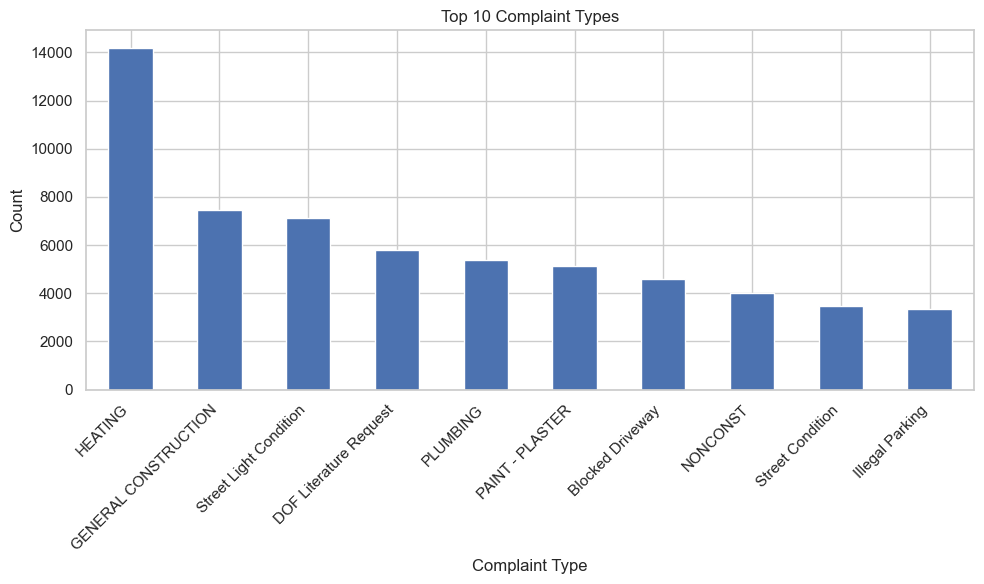

In [48]:
# Style
sns.set(style="whitegrid")

# Top complaint types
top_complaints = df['complaint_type'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_complaints.plot(kind='bar')
plt.title('Top 10 Complaint Types')
plt.xlabel('Complaint Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("visuals/top_complaints.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight
A few complaint types make up most of the volume, with Heating, General Construction, and Street Light Condition leading the dataset.

**2. Top Agencies by Complaint Volume**

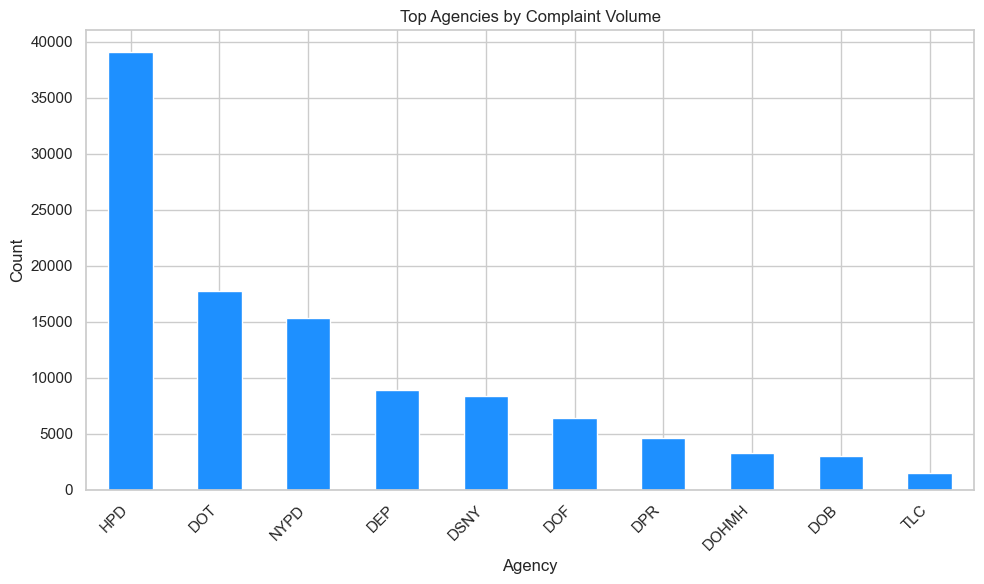

In [49]:
plt.figure(figsize=(10,6))
agency_counts = df['agency'].value_counts().head(10)
agency_counts.plot(kind='bar', color='dodgerblue')
plt.title('Top Agencies by Complaint Volume')
plt.xlabel('Agency')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("visuals/agency_complaints.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight
A small number of agencies handle most complaints, showing that service demand is concentrated across departments rather than evenly spread.

**4. Resolution Time Distribution**

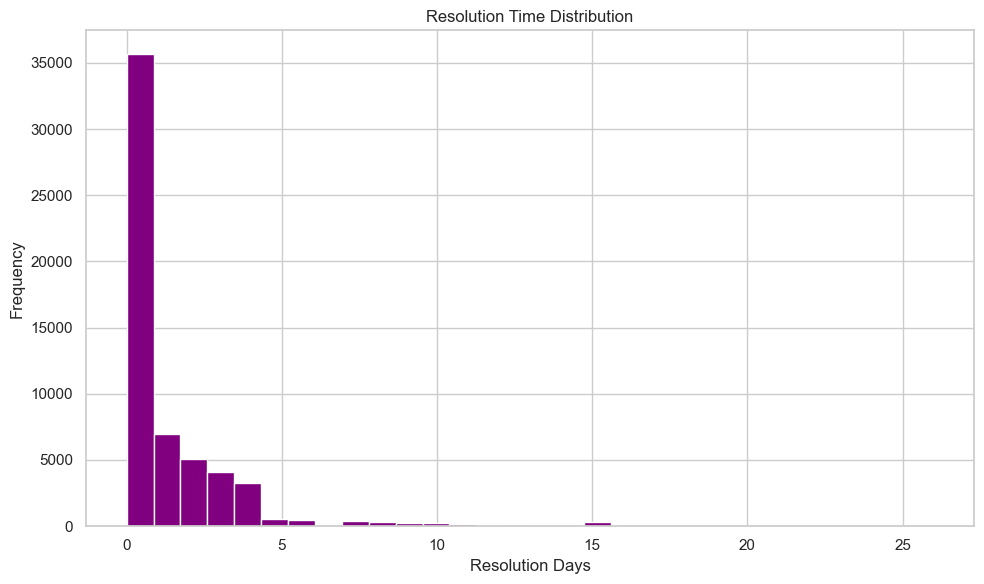

In [50]:
plt.figure(figsize=(10,6))
df[df['resolution_days'].notna()]['resolution_days'].plot(kind='hist', bins=30, color='purple')
plt.title('Resolution Time Distribution')
plt.xlabel('Resolution Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("visuals/resolution_time_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**4.1. Complaint by Month**

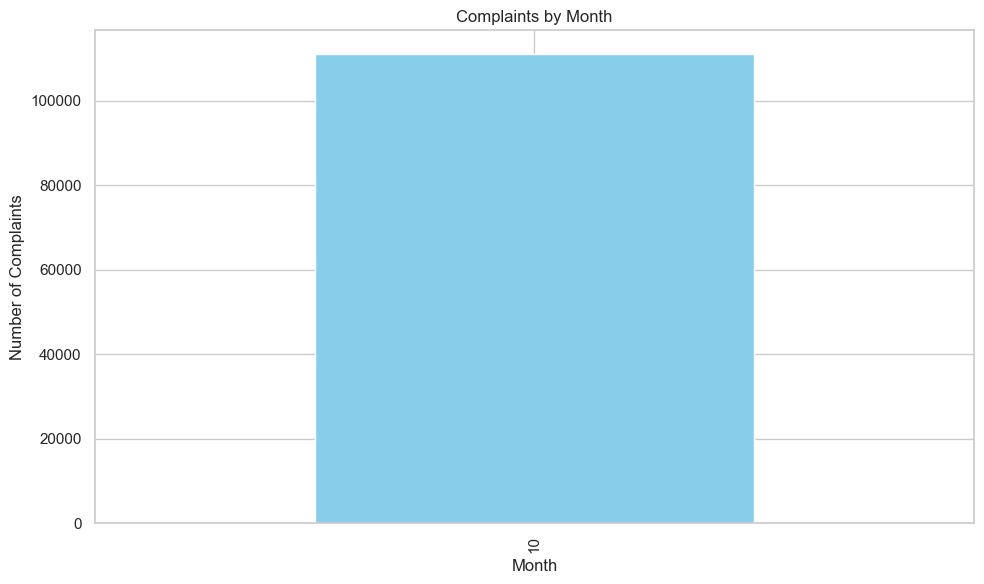

In [51]:
monthly_counts = df['created_month'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
monthly_counts.plot(kind='bar', color='skyblue')
plt.title('Complaints by Month')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.savefig("visuals/complaints_by_month.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight
The month distribution shows that the dataset is concentrated in one month, so long-term seasonality cannot be analyzed from this sample alone.

**4.2. Complaint by Month**

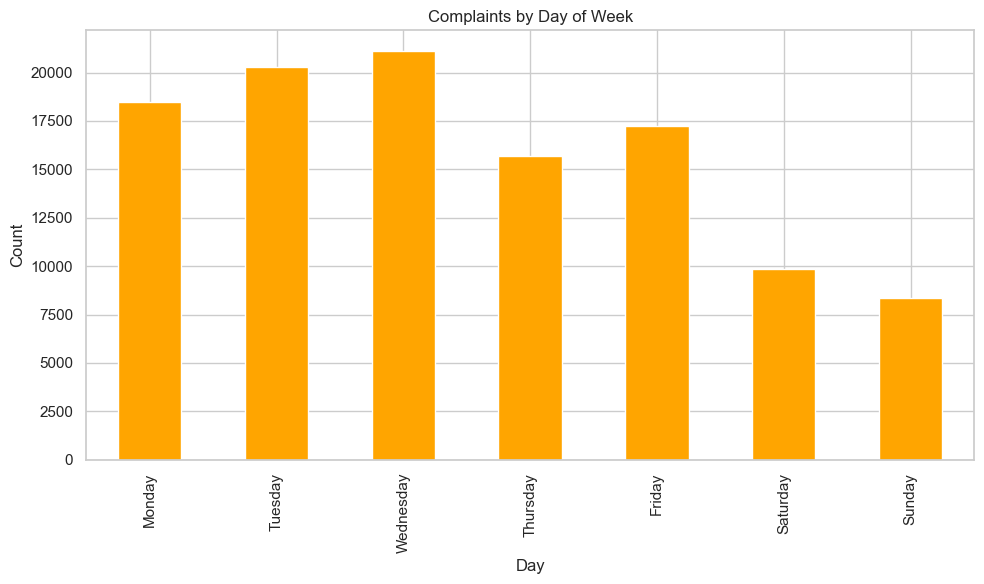

In [52]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['created_day_of_week'].value_counts().reindex(day_order, fill_value=0)
plt.figure(figsize=(10, 6))
day_counts.plot(kind='bar', color='orange')
plt.title('Complaints by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("visuals/complaints_by_day.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight
Complaints are higher on weekdays, especially midweek, and drop on weekends. This suggests request volume follows a regular work-week pattern.

In [53]:
plt.figure(figsize=(10, 6))
# your plotting code
plt.tight_layout()
plt.savefig("visuals/chart_name.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

**5. Complaint count by borough**

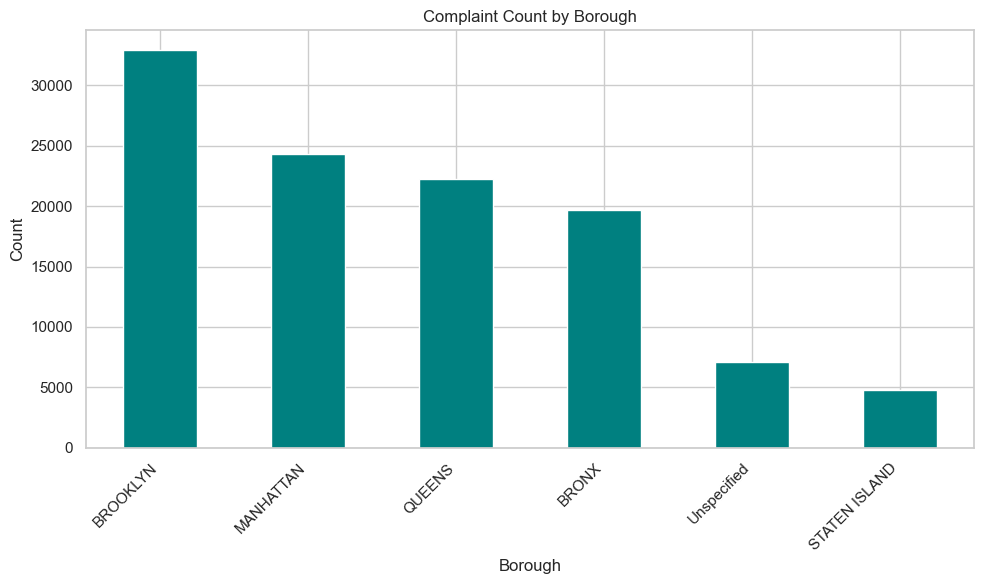

In [54]:
plt.figure(figsize=(10, 6))
borough_counts = df['borough'].value_counts()
borough_counts.plot(kind='bar', color='teal')
plt.title('Complaint Count by Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("visuals/borough_complaints.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight
Different boroughs are dominated by different complaint types, which suggests location-specific service issues rather than one citywide pattern.

**6. Top agencies by complaint volume**

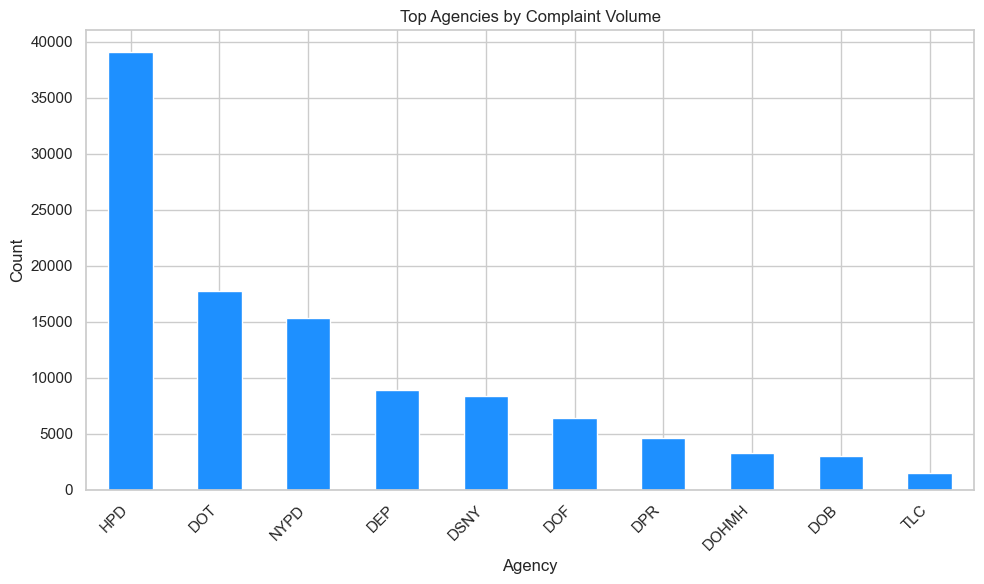

In [55]:
plt.figure(figsize=(10, 6))
agency_counts = df['agency'].value_counts().head(10)
agency_counts.plot(kind='bar', color='dodgerblue')
plt.title('Top Agencies by Complaint Volume')
plt.xlabel('Agency')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("visuals/agency_complaints.png", dpi=300, bbox_inches="tight")
plt.show()

**7. Resolution time distribution**

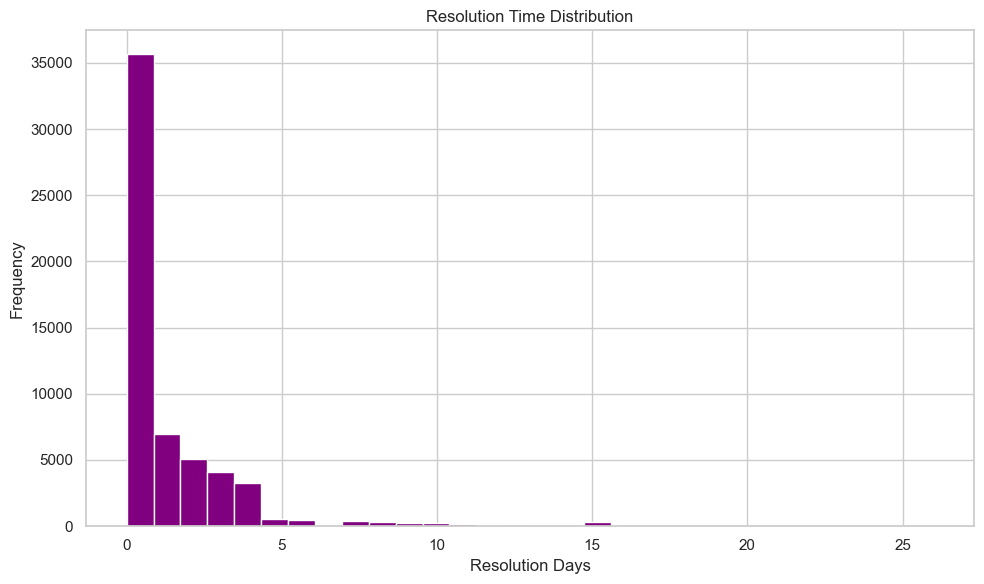

In [56]:
plt.figure(figsize=(10, 6))
df[df['resolution_days'].notna()]['resolution_days'].plot(kind='hist', bins=30, color='purple')
plt.title('Resolution Time Distribution')
plt.xlabel('Resolution Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("visuals/resolution_time_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight
Most complaints are resolved quickly, while a smaller group takes longer. The distribution is strongly right-skewed, with a few delayed cases stretching the tail.

**8. Open vs closed complaints**

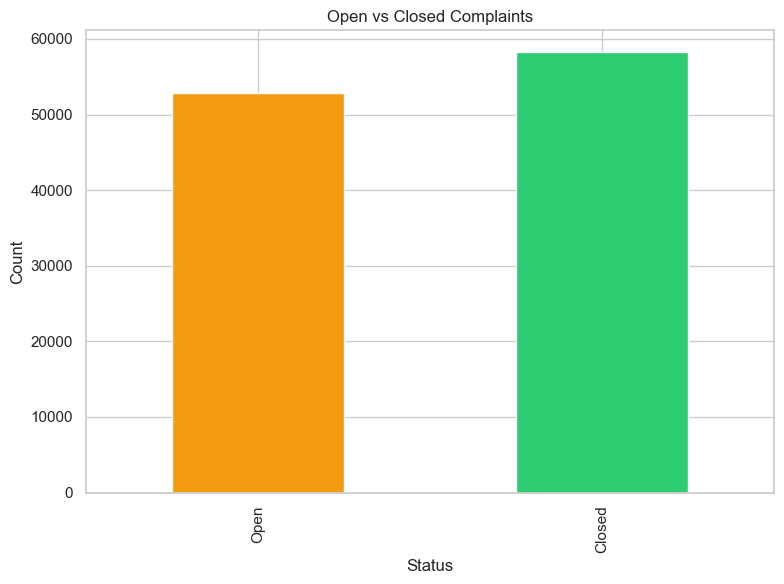

In [57]:
open_closed = pd.Series({
    'Open': df['closed_date'].isna().sum(),
    'Closed': df['closed_date'].notna().sum()
})

plt.figure(figsize=(8, 6))
open_closed.plot(kind='bar', color=['#f39c12', '#2ecc71'])
plt.title('Open vs Closed Complaints')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("visuals/open_vs_closed.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight
The dataset contains a large number of open complaints, showing that many requests are still unresolved and must be treated separately from closed cases.

**9. Top complaint types pie chart**

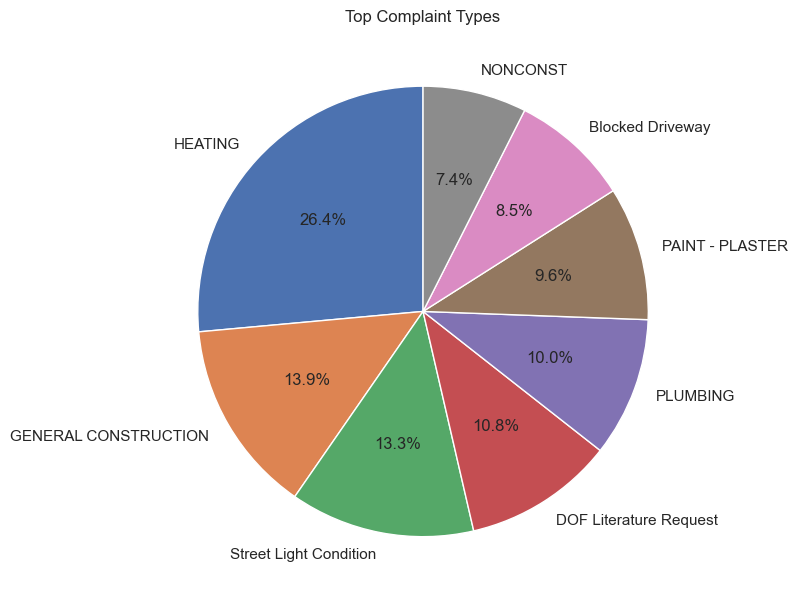

In [58]:
top_types = df['complaint_type'].value_counts().head(8)
plt.figure(figsize=(8, 8))
plt.pie(top_types.values, labels=top_types.index, autopct='%1.1f%%', startangle=90)
plt.title('Top Complaint Types')
plt.tight_layout()
plt.savefig("visuals/top_complaint_types_pie.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight
The top complaint types account for a large share of all requests, confirming that complaint demand is concentrated in a small set of recurring issues.

**10.Complaint type by borough heatmap**

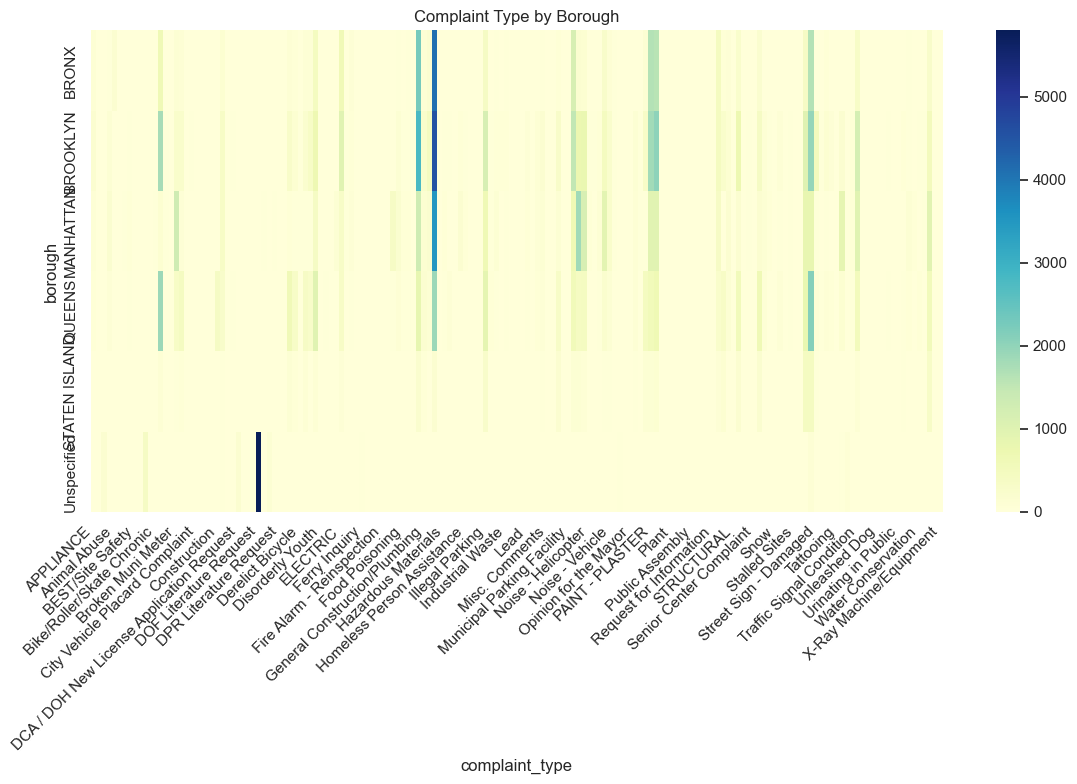

In [59]:
pivot = pd.crosstab(df['borough'], df['complaint_type']).head(10)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Complaint Type by Borough')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("visuals/borough_complaint_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight
Different boroughs are dominated by different complaint types, which suggests location-specific service issues rather than one citywide pattern.

## Diagnostic Analysis
The pattern is not random. A small number of complaint categories dominate the total volume, and this concentration is visible across agencies and boroughs. The data suggests that recurring city issues such as heating, general construction, and street light conditions create most of the demand on the system.

This pattern also appears geographically. Brooklyn and Manhattan generate the highest complaint volumes, while specific complaint types vary by borough, indicating that service issues are not evenly distributed across the city. The date and time analysis shows that complaints are concentrated during regular weekday operating patterns, which points to predictable demand rather than isolated spikes.

The resolution-time distribution shows that most complaints are resolved quickly, but a small number of long-running cases stretch the tail of the distribution. This indicates that while most service requests are handled efficiently, a minority of more complex complaints require longer intervention and create operational drag.

Together, these findings suggest that the main drivers are recurring issue types, borough-level demand concentration, and uneven agency workload. These are the areas most likely to benefit from targeted intervention and operational planning.

## Statistical Analysis

### Descriptive Statistics
The resolution-time distribution is strongly right-skewed, with most complaints resolved quickly and a small number of long-running cases increasing the mean. The median resolution time is low, which indicates that most requests are handled rapidly.

### Correlation
The dataset does not show a strong linear relationship between key operational fields, but it does reveal structured variation across locations and complaint types. This is useful because it suggests that complaint demand is driven by operational patterns rather than random noise.

### Business Interpretation
The statistical summary reinforces the visual findings: complaint volume is concentrated, service response is fast for most cases, and a small number of complaint types and agencies dominate the workload.

## Recommendations
- Prioritize recurring complaint types such as heating, street light issues, and construction-related problems.
- Allocate more operational capacity to boroughs with the highest complaint volume, especially Brooklyn and Manhattan.
- Review agency workloads to detect overloaded departments and redistribute resources where needed.
- Track resolution time by complaint type to identify which issues require longer intervention.
- Improve data consistency for `Closed Date` and missing location fields to increase the quality of future analysis.

## Conclusion
The data was audited, cleaned, enriched with time-based features, and explored through visual analysis to identify patterns in complaint volume, agency load, borough demand, and resolution time.

The main findings show that a small number of complaint types and agencies drive most of the demand, while a large share of complaints is resolved quickly. However, a meaningful number of cases remain open, and some records contain date inconsistencies that must be handled carefully during analysis. These are realistic challenges in operational data and are important to address when building reliable insights.

Overall, the project highlights both technical skill and business understanding. It shows that the analyst can take raw service-request data, clean it, detect patterns, and translate them into operational insights that are relevant to city services and resource planning.